# Classic Models

In [8]:
# import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [9]:
# Load the merged LLM dataset
df = pd.read_csv('llm_data/llm-dataset/eli5_all_llm_answers_cleaned.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Original dataset shape: (20000, 5)
Columns: ['q_id', 'question', 'chatgpt', 'deepseek', 'gemini']


,q_id,question,chatgpt,deepseek,gemini
0,5lchat,Why there was a 'leap second' added to the end...,"Okay, so imagine you have a big clock that hel...",Think of Earth like a spinning top that's slow...,Imagine we have a super-duper perfect clock th...
1,5lcjq6,How do you claim undiscovered land?,Claiming undiscovered land means saying that a...,You can't just go and claim any empty land you...,"Imagine you're exploring a giant playground, a..."
2,5lcl43,Why do we fail to do realistic human CGI (like...,"Okay, so imagine you have a really cool toy th...",We can make amazing CGI animals and monsters b...,Imagine you have a picture of your mommy or da...
3,5lcr1h,Why is it that we calm down when we take a dee...,"When you take a deep breath, it's like giving ...","When you feel scared or upset, your body gets ...",You know how sometimes when you're super excit...
4,5lcsyf,Why does 1080p on a 4k TV look better than 108...,"Okay, imagine you have two different kinds of ...",Imagine your TV screen is made of tiny light s...,Imagine your TV screen is like a giant board m...


In [10]:
# Separate each LLM answer into its own instance with an author column
instances = []

# Iterate through each row
for idx, row in df.iterrows():
    q_id = row['q_id']
    question = row['question']
    
    # Create an instance for each LLM
    for llm in ['chatgpt', 'deepseek', 'gemini']:
        instances.append({
            'q_id': q_id,
            'question': question,
            'answer': row[llm],
            'author': llm
        })

# Create the new dataframe
df = pd.DataFrame(instances)

print(f"Transformed dataset shape: {df.shape}")

print(f"\nAuthor distribution:")
print(df['author'].value_counts())

Transformed dataset shape: (60000, 4)

Author distribution:
author
chatgpt     20000
deepseek    20000
gemini      20000
Name: count, dtype: int64


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=None, 
    lowercase=True,
    ngram_range=(2, 3),  # unigrams + bigrams
    min_df=15,             # ignore very rare terms (appear in fewer than 15 documents)
    max_df=1.0,            #  do not ignore very common terms (can help differentiate authors)
    sublinear_tf=True     
)

tf_idf = vectorizer.fit_transform(df["answer"])
terms = vectorizer.get_feature_names_out()
print("TF-IDF shape:", tf_idf.shape)

TF-IDF shape: (60000, 88146)


Before training the model, we will perform an 80/20 train/test split

In [12]:
# 80/20 train/test split, stratified by author to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    tf_idf,
    df["author"],
    test_size=0.2,
    random_state=67,
    stratify=df["author"]
)

### Classic Model #1: Logistic Regression

Logistic regression is one of the supervised machine learning models used for this task, since this requires multiclass classification (ChatGPT, Gemini, DeepSeek)

              precision    recall  f1-score   support

     chatgpt     0.9588    0.9495    0.9542      4000
    deepseek     0.9355    0.9577    0.9465      4000
      gemini     0.9726    0.9590    0.9658      4000

    accuracy                         0.9554     12000
   macro avg     0.9557    0.9554    0.9555     12000
weighted avg     0.9557    0.9554    0.9555     12000



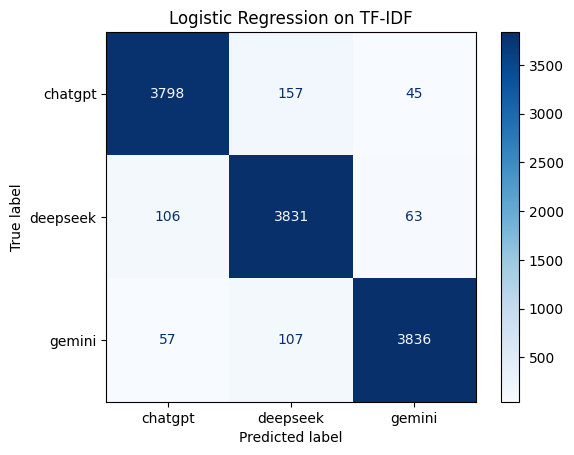

In [13]:
# train and fit
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["chatgpt", "deepseek", "gemini"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression on TF-IDF")
plt.show()

#### Classic Model 2: **Support Vector Machine (SVM)**

An SVM is a supervised machine learning models that classifies data by finding an optimal hyperplane or line that maximizes the distance between each class in an N-dimensional space [1].

SVM is optimized for high-dimensional text data. It also focuses on "confusing" responses at the boundaries to better identify between authors and ensure high classification accuracy.

In [14]:
# import SVM library
from sklearn.svm import SVC

A linear kernel can help avoid overfitting. Here, the features are linearly separable. Linearly separable is defined as being able to draw a straight boundary that seperates the different classes.

              precision    recall  f1-score   support

     chatgpt     0.9586    0.9620    0.9603      4000
    deepseek     0.9492    0.9583    0.9537      4000
      gemini     0.9797    0.9670    0.9733      4000

    accuracy                         0.9624     12000
   macro avg     0.9625    0.9624    0.9625     12000
weighted avg     0.9625    0.9624    0.9625     12000



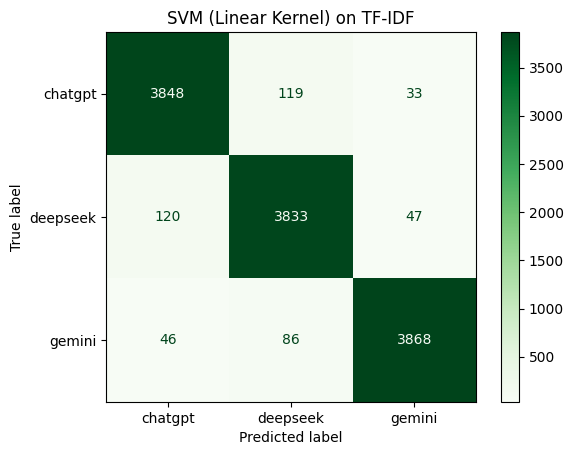

In [15]:
# train and fit SVM with linear kernel
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_linear_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_linear_svm, digits=4))

# confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_linear_svm, labels=["chatgpt", "deepseek", "gemini"])

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp_svm.plot(cmap="Greens", values_format="d")
plt.title("SVM (Linear Kernel) on TF-IDF")
plt.show()

An Radial Basis Function (RBF) Kernel can capture non-linear relationships by projecting data into an infinite-dimensional space. It can draw curved boundaries around specific clusters that a straight line would miss.

              precision    recall  f1-score   support

     chatgpt     0.9615    0.9555    0.9585      4000
    deepseek     0.9395    0.9623    0.9507      4000
      gemini     0.9784    0.9607    0.9695      4000

    accuracy                         0.9595     12000
   macro avg     0.9598    0.9595    0.9596     12000
weighted avg     0.9598    0.9595    0.9596     12000



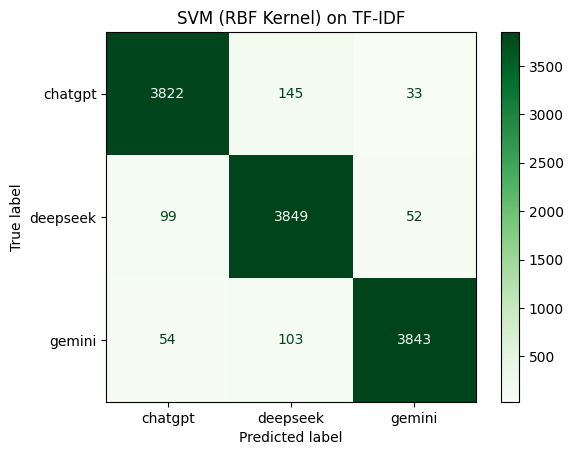

In [16]:
# train and fit SVM with rbf kernel
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_rbf_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_rbf_svm, digits=4))

# confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_rbf_svm, labels=["chatgpt", "deepseek", "gemini"])

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp_svm.plot(cmap="Greens", values_format="d")
plt.title("SVM (RBF Kernel) on TF-IDF")
plt.show()

In [17]:
print(classification_report(y_test, y_pred_linear_svm, digits=4))
print(classification_report(y_test, y_pred_rbf_svm, digits=4))

              precision    recall  f1-score   support

     chatgpt     0.9586    0.9620    0.9603      4000
    deepseek     0.9492    0.9583    0.9537      4000
      gemini     0.9797    0.9670    0.9733      4000

    accuracy                         0.9624     12000
   macro avg     0.9625    0.9624    0.9625     12000
weighted avg     0.9625    0.9624    0.9625     12000

              precision    recall  f1-score   support

     chatgpt     0.9615    0.9555    0.9585      4000
    deepseek     0.9395    0.9623    0.9507      4000
      gemini     0.9784    0.9607    0.9695      4000

    accuracy                         0.9595     12000
   macro avg     0.9598    0.9595    0.9596     12000
weighted avg     0.9598    0.9595    0.9596     12000


              precision    recall  f1-score   support

     chatgpt     0.9615    0.9555    0.9585      4000
    deepseek     0.9395    0.9623    0.9507      4000
      gemini     0.9784    0.9607    0.9695      4000

    accuracy       

#### Interpretation:

* The linear kernel had a slightly higher accuracy (95.77%), compared to the RBF (95.52%). The linear kernel's performance indicates that LLM stylistic signatures are linearly separable in high-dimensional space. This makes complex, non-linear transformations unnecessary for optimal classification.

[1] Kavlakoglu, E. (2023, December 12). Support Vector Machine. Ibm.com. https://www.ibm.com/think/topics/support-vector-machine